# TurtleBot — анализ контроллеров (CC + lateral)

Читает mcap-бэг из профиля `logging` (`ricar up logging`).
Графики: трекинг скорости (CC), поперечная/угловая ошибка (lateral), траектория vs полоса.

**Расширяемость:** переменная `NS` префиксует топики — для двух роботов задай `'/robot1'`/`'/robot2'`
и оберни загрузку в цикл (см. последнюю ячейку). Для ACC добавь топики gap/peer аналогично CC.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import rosbag2_py
from rclpy.serialization import deserialize_message
from rosidl_runtime_py.utilities import get_message


## Конфиг: где бэги + какой робот (NS)


In [3]:
# Куда скопированы логи с робота (/logs/auto_<id>_<ts>/ -> mcap-бэг = директория)
LOGS_ROOT = Path('/log_disk/logs').expanduser()      # поправь под себя
NS = '/alpha'                                 # namespace робота (VEHICLE_ID); для двух: '/robot1' / '/robot2'

def latest_bag(root: Path) -> Path:
    bags = [p for p in root.glob('auto_*') if (p/'metadata.yaml').exists()]
    if not bags:
        bags = [p for p in root.rglob('*') if (p/'metadata.yaml').exists()]
    assert bags, f'нет бэгов в {root}'
    return sorted(bags)[-1]

# BAG = latest_bag(LOGS_ROOT)
BAG = '/log_disk/logs/cc_lat_bravo'
print('bag:', BAG)

bag: /log_disk/logs/cc_lat_bravo


## Чтение mcap + извлекатели по типам


In [4]:
def load_bag(bag_dir: Path) -> dict:
    reader = rosbag2_py.SequentialReader()
    reader.open(rosbag2_py.StorageOptions(uri=str(bag_dir), storage_id='mcap'),
                rosbag2_py.ConverterOptions('', ''))
    types = {t.name: t.type for t in reader.get_all_topics_and_types()}
    out = {}
    while reader.has_next():
        topic, data, t = reader.read_next()
        msg = deserialize_message(data, get_message(types[topic]))
        out.setdefault(topic, []).append((t, msg))
    return out

# Единый ноль времени (ns) для ВСЕХ топиков — задаётся в ячейке загрузки после load_any.
# Иначе каждый топик нормируется от своего первого сообщения и графики разъезжаются по оси t
# (напр. /odom пишется раньше, чем /control/e_theta -> их нули не совпадают).
T0 = 0

def _t0(items):
    t = np.array([it[0] for it in items], float)
    return (t - T0) * 1e-9 if len(t) else t

def float_df(items):
    return pd.DataFrame({'t': _t0(items), 'v': [it[1].data for it in items]}) if items else pd.DataFrame(columns=['t','v'])

def _yaw(q):
    return np.arctan2(2*(q.w*q.z + q.x*q.y), 1 - 2*(q.y*q.y + q.z*q.z))

def odom_df(items):
    if not items: return pd.DataFrame(columns=['t','x','y','yaw','vx','wz'])
    P  = [it[1].pose.pose for it in items]
    Tw = [it[1].twist.twist for it in items]
    return pd.DataFrame({'t': _t0(items),
        'x':[p.position.x for p in P], 'y':[p.position.y for p in P],
        'yaw':[_yaw(p.orientation) for p in P],
        'vx':[w.linear.x for w in Tw], 'wz':[w.angular.z for w in Tw]})

def path_xy(items):
    if not items: return np.empty((0,2))
    msg = items[-1][1]
    return np.array([[p.pose.position.x, p.pose.position.y] for p in msg.poses])

## Загрузка топиков (с префиксом NS)


In [5]:
def T(s): return f'{NS}{s}'

# Загрузка бэга: сначала rosbag2 (нужен storage-плагин mcap в окружении ядра Jupyter),
# при его отсутствии — ПРЯМОЙ mcap-ридер: pip install mcap mcap-ros2-support.
# mcap самодостаточен — схемы сообщений лежат внутри файла, ROS/rosbag2 для чтения не нужны.
def load_any(bag) -> dict:
    try:
        return load_bag(Path(bag))
    except Exception as e:
        print(f'[load] rosbag2 не смог ({type(e).__name__}); читаю .mcap напрямую (mcap-ros2-support)')
        from mcap_ros2.reader import read_ros2_messages
        bag = Path(bag)
        mcaps = sorted(bag.glob('*.mcap')) if bag.is_dir() else [bag]
        assert mcaps, f'нет .mcap в {bag}'
        out = {}
        for mc in mcaps:
            for m in read_ros2_messages(str(mc)):
                out.setdefault(m.channel.topic, []).append((m.log_time, m.ros_msg))
        return out

data = load_any(BAG)
print('топиков в бэге:', len(data))

# ЕДИНЫЙ ноль времени по всем топикам (самый ранний таймстамп в бэге) — чтобы графики
# разных топиков (odom, e_theta, ...) лежали на одной оси t. ВАЖНО: задать ДО float_df/odom_df,
# т.к. _t0 вычитает глобальный T0 (см. ячейку с извлекателями).
global T0
T0 = min((v[0][0] for v in data.values() if v), default=0)

cc  = {k: float_df(data.get(T(f'/control/{k}'), [])) for k in ['v_ref','v_meas','v_cmd','v_error']}
lat = {k: float_df(data.get(T(f'/control/{k}'), [])) for k in ['e_lat','e_theta','w_cmd','w_meas']}
odom = odom_df(data.get(T('/odom'), []))
lio  = odom_df(data.get(T('/lio_sam/mapping/odometry'), []))
path = path_xy(data.get(T('/control/pacemaker/path'), []))   # полоса (под namespace control)

[WARN] [1782043581.572071931] [rosbag2_storage_mcap]: no message indices found, falling back to reading in file order


топиков в бэге: 21


## CC: трекинг скорости


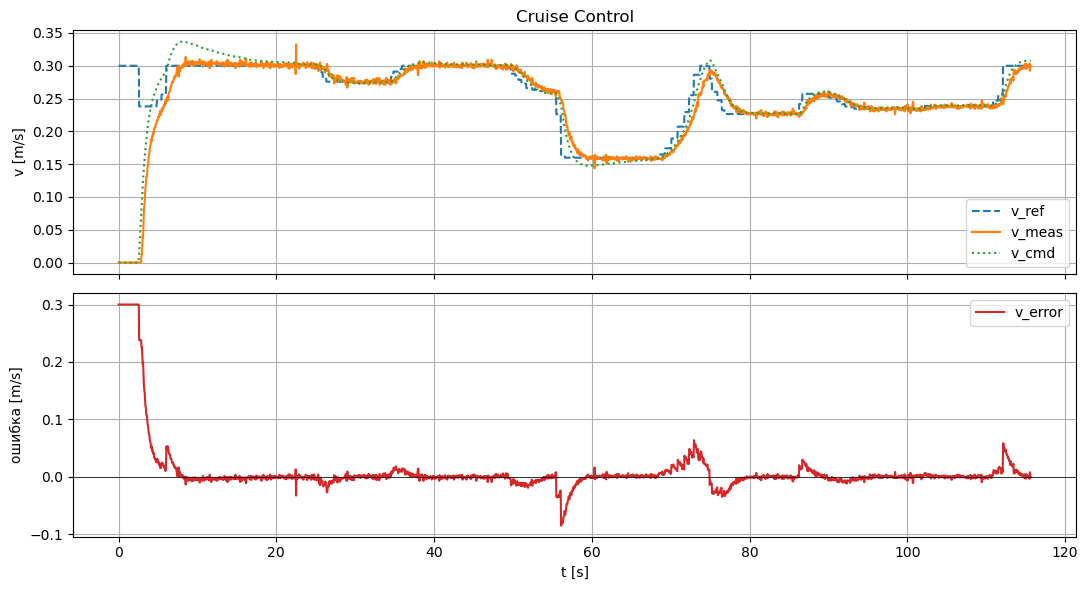

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(11,6), sharex=True)
for k, st in [('v_ref','--'),('v_meas','-'),('v_cmd',':')]:
    d = cc[k]
    if len(d): ax[0].plot(d['t'].to_numpy(), d['v'].to_numpy(), st, label=k)
ax[0].set_ylabel('v [m/s]'); ax[0].legend(); ax[0].grid(True); ax[0].set_title('Cruise Control')
if len(cc['v_error']): ax[1].plot(cc['v_error']['t'].to_numpy(), cc['v_error']['v'].to_numpy(), color='tab:red', label='v_error')
ax[1].axhline(0, color='k', lw=0.5); ax[1].set_ylabel('ошибка [m/s]'); ax[1].set_xlabel('t [s]'); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

## Lateral: поперечная и угловая ошибка


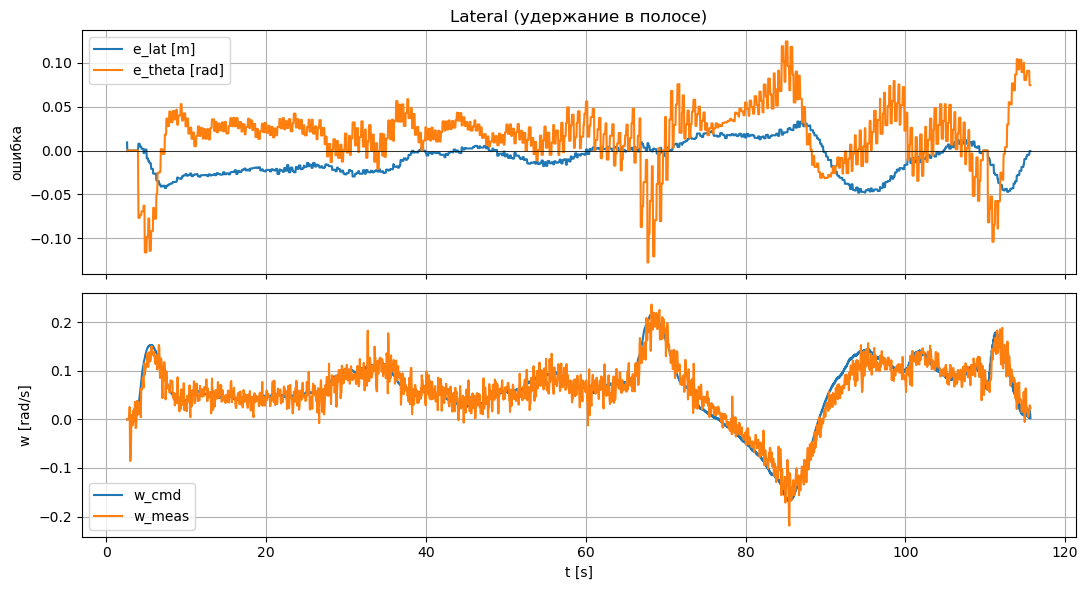

e_lat: RMS=0.0203 m, max|e|=0.0479 m


In [6]:
fig, ax = plt.subplots(2, 1, figsize=(11,6), sharex=True)
if len(lat['e_lat']):   ax[0].plot(lat['e_lat']['t'].to_numpy(),   lat['e_lat']['v'].to_numpy(),   label='e_lat [m]')
if len(lat['e_theta']): ax[0].plot(lat['e_theta']['t'].to_numpy(), lat['e_theta']['v'].to_numpy(), label='e_theta [rad]')
ax[0].axhline(0, color='k', lw=0.5); ax[0].set_ylabel('ошибка'); ax[0].legend(); ax[0].grid(True); ax[0].set_title('Lateral (удержание в полосе)')
for k in ['w_cmd','w_meas']:
    d = lat[k]
    if len(d): ax[1].plot(d['t'].to_numpy(), d['v'].to_numpy(), label=k)
ax[1].set_ylabel('w [rad/s]'); ax[1].set_xlabel('t [s]'); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

if len(lat['e_lat']):
    e = lat['e_lat']['v'].to_numpy()
    print(f'e_lat: RMS={np.sqrt(np.mean(e**2)):.4f} m, max|e|={np.max(np.abs(e)):.4f} m')

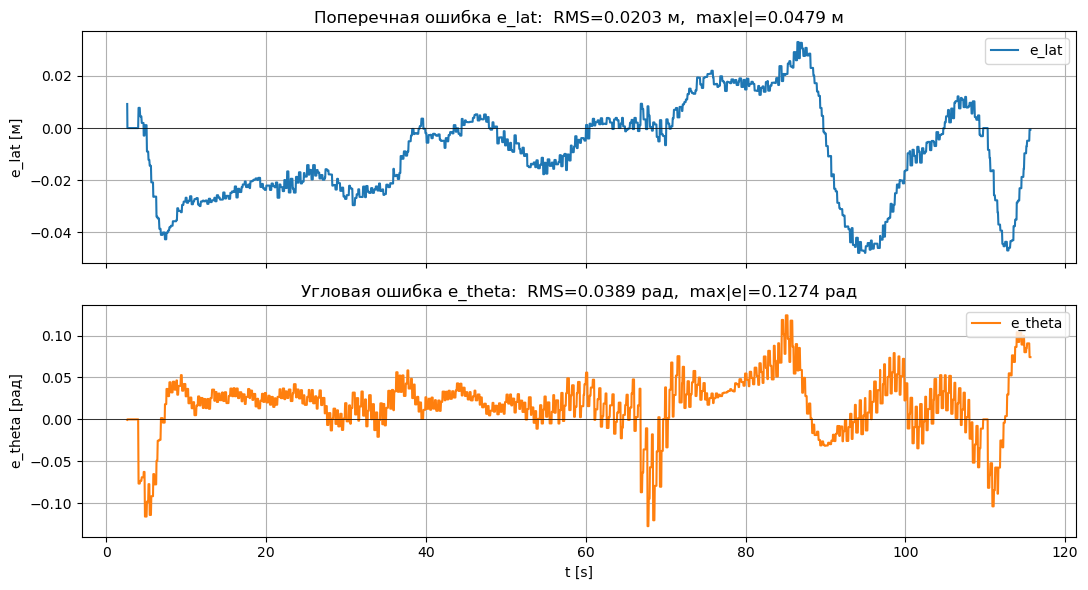

In [7]:
# Раздельно: поперечная (e_lat) и угловая (e_theta) ошибки — каждая на своей оси
fig, ax = plt.subplots(2, 1, figsize=(11,6), sharex=True)

if len(lat['e_lat']):
    e = lat['e_lat']['v'].to_numpy()
    ax[0].plot(lat['e_lat']['t'].to_numpy(), e, color='tab:blue', label='e_lat')
    ax[0].set_title(f"Поперечная ошибка e_lat:  RMS={np.sqrt(np.mean(e**2)):.4f} м,  max|e|={np.max(np.abs(e)):.4f} м")
ax[0].axhline(0, color='k', lw=0.5); ax[0].set_ylabel('e_lat [м]'); ax[0].legend(loc='upper right'); ax[0].grid(True)

if len(lat['e_theta']):
    et = lat['e_theta']['v'].to_numpy()
    ax[1].plot(lat['e_theta']['t'].to_numpy(), et, color='tab:orange', label='e_theta')
    ax[1].set_title(f"Угловая ошибка e_theta:  RMS={np.sqrt(np.mean(et**2)):.4f} рад,  max|e|={np.max(np.abs(et)):.4f} рад")
ax[1].axhline(0, color='k', lw=0.5); ax[1].set_ylabel('e_theta [рад]'); ax[1].set_xlabel('t [s]'); ax[1].legend(loc='upper right'); ax[1].grid(True)

plt.tight_layout(); plt.show()

--- ЛОКАЛИЗАЦИЯ на стоянке (lio_sam, 9 сэмплов, 1с) ---
  σ_x=0.16 см  σ_y=0.12 см  σ_planar=0.06 см  σ_yaw=0.01°
  размах planar p2p=0.19 см

--- e_lat (2261 сэмплов, fs~20 Гц) ---
  σ_total=1.81 см   σ_НЧ(реальное)=1.80 см   σ_ВЧ(шум)=0.18 см
  СРАВНЕНИЕ: σ_ВЧ(e_lat)=0.18 см  vs  σ_planar(локализация на стоянке)=0.06 см
  доля дисперсии e_lat в ВЧ (≈ вклад шума): 1%


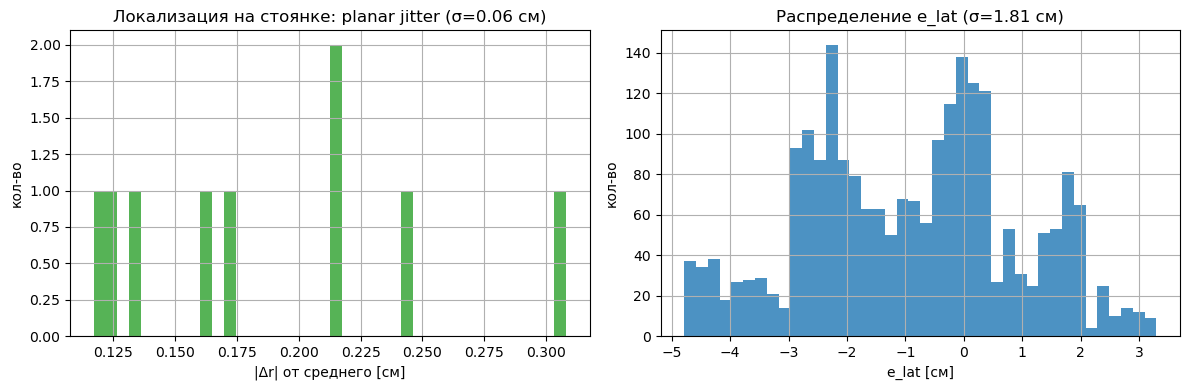

In [8]:
# ===== Гипотеза: шум локализации lio_sam подмешивается в e_lat (и провоцирует раскачку) =====
# e_lat считается из позы lio_sam (Frenet), поэтому шум позы входит в e_lat ~1:1.
# (1) шум локализации на СТОЯНКЕ (до старта, v=0) -> «пол шума»;
# (2) распределение e_lat: НЧ (реальное отклонение) vs ВЧ (шум/реакция на шум).

# --- (1) локализация на стоянке: окно покоя до начала движения ---
t_move = float(lat['e_lat']['t'].iloc[0]) if len(lat['e_lat']) else float(odom['t'].iloc[-1])
stat = lio[(lio['t'] > t_move - 30) & (lio['t'] < t_move - 1)].copy()   # ~30с покоя перед стартом
loc = {}
if len(stat) > 5:
    for c in ['x', 'y', 'yaw']:
        loc[c] = (stat[c] - stat[c].mean()).to_numpy()
    planar = np.hypot(loc['x'], loc['y'])
    dur = float(stat['t'].iloc[-1] - stat['t'].iloc[0])
    print(f'--- ЛОКАЛИЗАЦИЯ на стоянке (lio_sam, {len(stat)} сэмплов, {dur:.0f}с) ---')
    print(f"  σ_x={loc['x'].std()*100:.2f} см  σ_y={loc['y'].std()*100:.2f} см  "
          f"σ_planar={planar.std()*100:.2f} см  σ_yaw={np.degrees(loc['yaw'].std()):.2f}°")
    print(f"  размах planar p2p={planar.ptp()*100:.2f} см")
else:
    planar = np.array([])
    print('! нет чистого неподвижного окна lio до старта — поправь границы окна stat')

# --- (2) распределение e_lat: НЧ vs ВЧ ---
if len(lat['e_lat']):
    e = lat['e_lat'][['t', 'v']].copy()
    fs = 1.0 / float(np.median(np.diff(e['t'].to_numpy())))   # частота семплов e_lat
    win = max(1, int(round(1.0 * fs)))                        # окно сглаживания ~1с
    e['slow'] = e['v'].rolling(win, center=True, min_periods=1).mean()  # НЧ = реальное отклонение
    e['hf'] = e['v'] - e['slow']                                        # ВЧ = шум/дрожь
    print(f'\n--- e_lat ({len(e)} сэмплов, fs~{fs:.0f} Гц) ---')
    print(f"  σ_total={e['v'].std()*100:.2f} см   σ_НЧ(реальное)={e['slow'].std()*100:.2f} см   "
          f"σ_ВЧ(шум)={e['hf'].std()*100:.2f} см")
    if len(planar):
        print(f"  СРАВНЕНИЕ: σ_ВЧ(e_lat)={e['hf'].std()*100:.2f} см  vs  "
              f"σ_planar(локализация на стоянке)={planar.std()*100:.2f} см")
        print(f"  доля дисперсии e_lat в ВЧ (≈ вклад шума): {(e['hf'].std()/e['v'].std())**2*100:.0f}%")

# --- распределения ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
if len(planar):
    ax[0].hist(planar * 100, bins=40, color='tab:green', alpha=0.8)
    ax[0].set_title(f'Локализация на стоянке: planar jitter (σ={planar.std()*100:.2f} см)')
    ax[0].set_xlabel('|Δr| от среднего [см]')
if len(lat['e_lat']):
    ax[1].hist(e['v'].to_numpy() * 100, bins=40, color='tab:blue', alpha=0.8)
    ax[1].set_title(f"Распределение e_lat (σ={e['v'].std()*100:.2f} см)")
    ax[1].set_xlabel('e_lat [см]')
for a in ax:
    a.grid(True); a.set_ylabel('кол-во')
plt.tight_layout(); plt.show()

лаг w_meas за w_cmd ≈ 300 мс  (пик корреляции 0.96)
-> ориентир tau_w ~ 0.300 с (для 1-го порядка tau≈лаг)


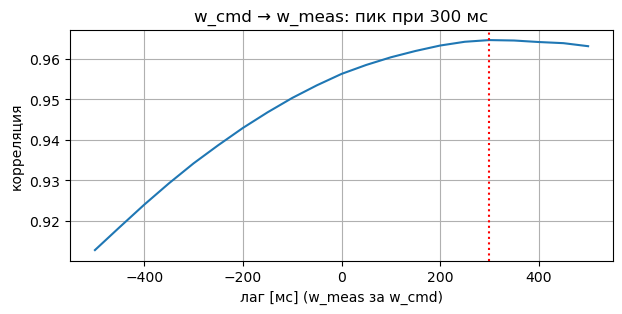

In [9]:
# Реальный лаг углового привода kobuki: сдвиг w_cmd -> w_meas (ориентир для tau_w).
# Если лаг мал (~50 мс) -> tau_w можно держать малым (острее на кривых);
# если велик (~150 мс) -> tau_w нужен больше.
wc, wm = lat['w_cmd'], lat['w_meas']
if len(wc) > 10 and len(wm) > 10:
    dt = 0.05
    t0, t1 = max(wc['t'].iloc[0], wm['t'].iloc[0]), min(wc['t'].iloc[-1], wm['t'].iloc[-1])
    tg = np.arange(t0, t1, dt)
    c = np.interp(tg, wc['t'].to_numpy(), wc['v'].to_numpy())
    m = np.interp(tg, wm['t'].to_numpy(), wm['v'].to_numpy())
    c, m = c - c.mean(), m - m.mean()
    maxlag = int(round(0.5 / dt))
    lags = np.arange(-maxlag, maxlag + 1)
    xcorr = np.array([np.corrcoef(c[:len(c) - L], m[L:])[0, 1] if L >= 0
                      else np.corrcoef(c[-L:], m[:len(m) + L])[0, 1] for L in lags])
    best = lags[np.nanargmax(xcorr)] * dt
    print(f'лаг w_meas за w_cmd ≈ {best * 1000:.0f} мс  (пик корреляции {np.nanmax(xcorr):.2f})')
    print(f'-> ориентир tau_w ~ {max(best, 0.0):.3f} с (для 1-го порядка tau≈лаг)')
    plt.figure(figsize=(7, 3))
    plt.plot(lags * dt * 1000, xcorr); plt.axvline(best * 1000, color='r', ls=':')
    plt.xlabel('лаг [мс] (w_meas за w_cmd)'); plt.ylabel('корреляция'); plt.grid(True)
    plt.title(f'w_cmd → w_meas: пик при {best * 1000:.0f} мс'); plt.show()
else:
    print('мало данных w_cmd/w_meas для оценки лага')

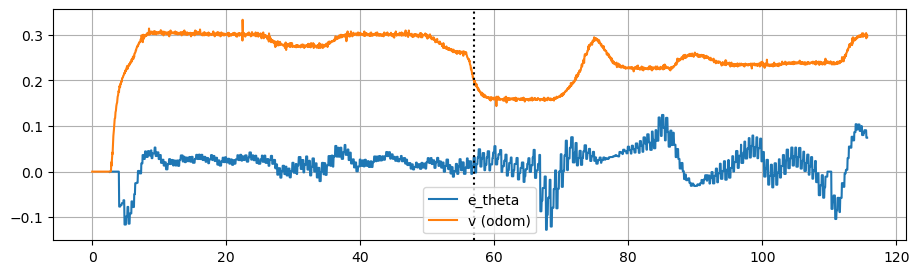

In [10]:
plt.figure(figsize=(11,3))
plt.plot(lat['e_theta']['t'].to_numpy(), lat['e_theta']['v'].to_numpy(), label='e_theta')
plt.plot(odom['t'].to_numpy(), odom['vx'].to_numpy(), label='v (odom)')   # или cc['v_cmd']
plt.axvline(57, color='k', ls=':'); plt.legend(); plt.grid(True); plt.show()

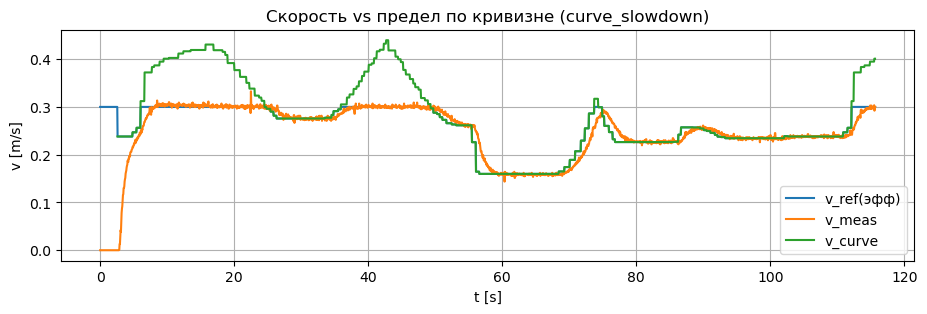

In [11]:
# Скорость vs предел по кривизне (самодостаточно: из data, не зависит от dict cc)
vref   = float_df(data.get(T('/control/v_ref'),   []))   # эффективная цель (CC уже взял min с v_curve)
vmeas  = float_df(data.get(T('/control/v_meas'),  []))
vcurve = float_df(data.get(T('/control/v_curve'), []))   # предел по кривизне (lat-нода)
plt.figure(figsize=(11, 3))
for d, l in [(vref, 'v_ref(эфф)'), (vmeas, 'v_meas'), (vcurve, 'v_curve')]:
    if len(d):
        plt.plot(d['t'].to_numpy(), d['v'].to_numpy(), label=l)
plt.legend(); plt.grid(True); plt.ylabel('v [m/s]'); plt.xlabel('t [s]')
plt.title('Скорость vs предел по кривизне (curve_slowdown)'); plt.show()

In [12]:
for name, df in [('v_ref(эфф)', vref), ('v_meas', vmeas), ('v_curve', vcurve)]:
    seg = df[df['t'] > 70]['v']
    if len(seg): print(f'{name:11s} t>70:  mean={seg.mean():.3f}  min={seg.min():.3f}  max={seg.max():.3f}')


v_ref(эфф)  t>70:  mean=0.244  min=0.174  max=0.300
v_meas      t>70:  mean=0.241  min=0.168  max=0.303
v_curve     t>70:  mean=0.250  min=0.174  max=0.401


In [13]:
vref  = float_df(data.get(T('/control/v_ref'),  []))
vcmd  = float_df(data.get(T('/control/v_cmd'),  []))
vmeas = float_df(data.get(T('/control/v_meas'), []))
for name, df in [('v_ref', vref), ('v_cmd', vcmd), ('v_meas', vmeas)]:
    seg = df[df['t'] > 70]['v']
    if len(seg): print(f'{name:7s} mean={seg.mean():.3f} min={seg.min():.3f} max={seg.max():.3f}')


v_ref   mean=0.244 min=0.174 max=0.300
v_cmd   mean=0.245 min=0.170 max=0.308
v_meas  mean=0.241 min=0.168 max=0.303


## Траектория: lio_sam vs полоса


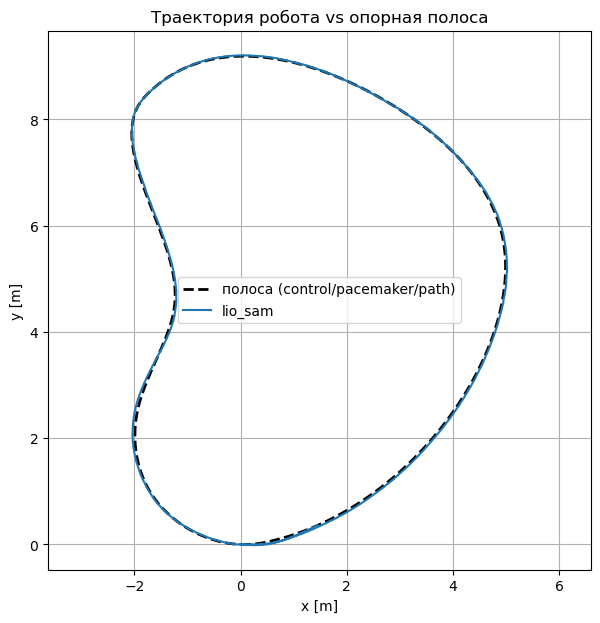

In [14]:
plt.figure(figsize=(7,7))
if len(path): plt.plot(path[:,0], path[:,1], 'k--', lw=2, label='полоса (control/pacemaker/path)')
if len(lio):  plt.plot(lio['x'].to_numpy(), lio['y'].to_numpy(), 'tab:blue', label='lio_sam')
plt.axis('equal'); plt.xlabel('x [m]'); plt.ylabel('y [m]'); plt.legend(); plt.grid(True)
plt.title('Траектория робота vs опорная полоса'); plt.show()

## Расширение под 2 робота / ACC

**Два робота:** задай `NS='/robot1'` и перезапусти ячейки, либо оберни в цикл:
```python
robots = {}
for ns in ['/robot1', '/robot2']:
    NS = ns
    robots[ns] = {
        'cc':  {k: float_df(data.get(f'{ns}/control/{k}', [])) for k in ['v_ref','v_meas','v_cmd','v_error']},
        'lio': odom_df(data.get(f'{ns}/lio_sam/mapping/odometry', [])),
    }
# затем наложить траектории/ошибки обоих на общих осях
```
(после namespacing бэг будет содержать `/robot1/...`, `/robot2/...`.)

**ACC (этап 2):** добавь gap/peer-топики по тому же паттерну, что CC:
```python
acc = {k: float_df(data.get(T(f'/control/{k}'), [])) for k in ['gap','gap_ref','gap_error','v_rel']}
```
и график `gap` vs `gap_ref` + `gap_error` (аналог CC v_ref/v_meas/v_error).
